# Visualize the multicell dataset

`MultiCellPatchDataset` (`src/python/extract_embeddings/data/patch_dataset.py`) tiles a
WSI into large patches and reads off many cells' tokens from a single forward pass,
instead of one crop per cell. This notebook visually checks its three configurable
pieces:

- **resize component** (`size_side_x` / `size_side_y`): crop each tile at a native
  pixel size different from the model's input size, then resize it down (or up) --
  the multicell analogue of `ResizedCellDataset`'s `size_side`.
- **central-crop restriction** (`central_size_x` / `central_size_y`): only extract
  cells that fall in a centred sub-window of each (post-resize) patch, so no
  extracted cell sits near a tile's edge with a lopsided/truncated field of view.
- **cell / nucleus boundary tokens**: same Xenium-derived `embeddings_cell` /
  `embeddings_nucleus` mean-pooled tokens as the per-cell extraction path
  (`InferenceProvider.pool_boundary_tokens`), computed here via
  `MultiCellPatchDataset.boundary_polygon` + `pool_boundary_tokens_multicell`.

See `README.md`'s "Reproducing the paper's read-out conditions" section and
`extract_embeddings.build_multicell_configs` for how to wire these into a real
extraction run.

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))


def _load_dotenv(path: Path) -> None:
    """Minimal `.env` loader (KEY=value per line) -- avoids an extra dependency.
    Mirrors how every other entry point in this repo expects env vars to be set
    (see src/python/code_configs/paths.py)."""
    if not path.exists():
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key, value = key.strip(), value.strip()
        if value:
            os.environ.setdefault(key, value)


_load_dotenv(REPO_ROOT / ".env")

In [2]:
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon as MplPolygon

from src.python.code_configs import paths
from src.python.extract_embeddings.data.patch_dataset import MultiCellPatchDataset
from src.python.extract_embeddings.data.xenium_boundaries import token_overlap_mask, nearest_token

## Config

Pick a **raw** (non-`converted`) dataset -- boundary-polygon mapping goes through the
Xenium<->H&E alignment matrix, which today is only exercised for raw WSIs (see
`extract_embeddings.py`'s entry point). `TOKEN_SIZE`/`X_SIZE`/`Y_SIZE` mirror UNI2's
`(patch_size, x_size, y_size)` exactly as hardcoded in `UNI2InferenceProvider.__init__`
-- keep in sync if you change models.

`CENTRAL_SIZE` and `SIZE_SIDE` are the two new dataset knobs -- set either to `None`
(or `CENTRAL_SIZE = X_SIZE`, `SIZE_SIDE = X_SIZE`) to fall back to the original
"one non-overlapping `X_SIZE`×`Y_SIZE` tile per patch, no resize" behaviour.

In [12]:
DATASET_NAME = "Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE"
WSI_FILENAME = f"{DATASET_NAME}_he_image.ome.tif"

# UNI2's token grid: 224x224 input, patch_size=14 -> 16x16 spatial tokens (see
# UNI2InferenceProvider) -- update if you change model/config.
TOKEN_SIZE = 14
X_SIZE = Y_SIZE = 224

# Central-crop restriction: only extract cells inside this centred sub-window of each
# (post-resize) patch -- see MultiCellPatchDataset's central_size_x/central_size_y.
CENTRAL_SIZE = 112

# Resize component: crop each tile at this native pixel size, then resize down to
# X_SIZE x Y_SIZE before it hits the model -- see MultiCellPatchDataset's
# size_side_x/size_side_y. Matches X_SIZE/Y_SIZE (i.e. no resize) here; the dedicated
# resize section further down overrides this to demonstrate the feature.
SIZE_SIDE = X_SIZE

wsi_path = os.path.join(paths.WSI_RAW_ROOT, WSI_FILENAME)
cells_info_path = os.path.join(paths.XENIUM_PROCESSED_OUTPUT_ROOT, DATASET_NAME, "patch_coordinates.h5")
cells_csv_path = os.path.join(paths.XENIUM_OUTPUT_ROOT, f"{DATASET_NAME}_out", "cell_boundaries.csv.gz")
nucleus_boundaries_path = os.path.join(paths.XENIUM_OUTPUT_ROOT, f"{DATASET_NAME}_out", "nucleus_boundaries.parquet")
alignment_matrix_path = os.path.join(paths.ALIGNMENT_MATRIX_ROOT, f"{DATASET_NAME}_he_imagealignment.csv")

## Datasets: baseline vs. central-restricted tiling

Both datasets are built from the same WSI/cells, wired with the Xenium boundary files
so `boundary_polygon()` works below. They should account for the exact same total
number of cells -- central-crop restriction changes *which* tile reads off a given
cell (and how much surrounding context that tile has), never *whether* it's read.

In [13]:
dataset_full = MultiCellPatchDataset(
    wsi_path=wsi_path,
    cells_info_path=cells_info_path,
    x_size=X_SIZE, y_size=Y_SIZE,
    cells_csv_path=cells_csv_path,
    nucleus_boundaries_path=nucleus_boundaries_path,
    alignment_matrix_path=alignment_matrix_path,
)

dataset_central = MultiCellPatchDataset(
    wsi_path=wsi_path,
    cells_info_path=cells_info_path,
    x_size=X_SIZE, y_size=Y_SIZE,
    central_size_x=CENTRAL_SIZE, central_size_y=CENTRAL_SIZE,
    cells_csv_path=cells_csv_path,
    nucleus_boundaries_path=nucleus_boundaries_path,
    alignment_matrix_path=alignment_matrix_path,
)

print(f"full patch tiling:   {len(dataset_full)} patches, {dataset_full.total_cells} cells")
print(f"central-crop tiling: {len(dataset_central)} patches, {dataset_central.total_cells} cells")
assert dataset_full.total_cells == dataset_central.total_cells, (
    "central-crop tiling must still claim every cell exactly once, just via more/smaller tiles"
)

Loading WSI from /cluster/work/boeva/mglettig/scHNE/complete_xenium_samples/H&E/Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_he_image.ome.tif and cell info from /cluster/work/boeva/mglettig/scHNE/complete_xenium_samples/processed_output/Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE/patch_coordinates.h5...
Found 8358 non-empty patches covering 263823 cells.


Loading WSI from /cluster/work/boeva/mglettig/scHNE/complete_xenium_samples/H&E/Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_he_image.ome.tif and cell info from /cluster/work/boeva/mglettig/scHNE/complete_xenium_samples/processed_output/Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE/patch_coordinates.h5...
Found 29414 non-empty patches covering 263823 cells (central 112x112 of 224x224).
full patch tiling:   8358 patches, 263823 cells
central-crop tiling: 29414 patches, 263823 cells


## Plotting helpers

`plot_multicell_patch` draws one patch: the model's token grid, the central
sub-window (if the dataset restricts to one), every assigned cell's centre, and
(optionally, capped at `max_boundary_cells` to keep dense patches legible) each
cell's Xenium **cell** boundary (blue) and **nucleus** boundary (orange).

In [14]:
_KIND_COLORS = {"cell": "tab:blue", "nucleus": "tab:orange"}


def _exterior_rings(geom):
    """Yield each constituent polygon's exterior ring as an (N, 2) array.
    boundary_polygon() can return a MultiPolygon -- e.g. make_valid() splits a
    self-intersecting Xenium boundary into its separate lobes -- so this draws
    every lobe instead of assuming a single Polygon."""
    if geom.geom_type == "Polygon":
        yield np.array(geom.exterior.coords)
    elif geom.geom_type == "MultiPolygon":
        for sub in geom.geoms:
            yield np.array(sub.exterior.coords)


def plot_multicell_patch(dataset, idx, ax=None, token_size=None, show_central_box=True,
                          show_boundaries=False, max_boundary_cells=6, color_by_label=False):
    p = dataset.patch_infos[idx]
    raw_patch = dataset.get_raw_patch(idx)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(raw_patch)

    if token_size:
        for t in range(0, dataset.x_size + 1, token_size):
            ax.axvline(t, color="white", linewidth=0.4, alpha=0.4)
            ax.axhline(t, color="white", linewidth=0.4, alpha=0.4)

    if show_central_box and (dataset.central_size_x < dataset.x_size or dataset.central_size_y < dataset.y_size):
        cx0 = (dataset.x_size - dataset.central_size_x) / 2
        cy0 = (dataset.y_size - dataset.central_size_y) / 2
        ax.add_patch(Rectangle((cx0, cy0), dataset.central_size_x, dataset.central_size_y,
                                facecolor="none", edgecolor="yellow", linewidth=2, linestyle="--"))

    labels = [l.decode("utf-8") if isinstance(l, bytes) else str(l) for l in p["cell_labels"]]
    if color_by_label:
        uniq = sorted(set(labels))
        cmap = plt.get_cmap("tab10")
        colors = [cmap(uniq.index(l) % 10) for l in labels]
    else:
        colors = "red"
    ax.scatter(p["cell_rel_x"], p["cell_rel_y"], s=14, c=colors, edgecolors="white", linewidths=0.6, zorder=5)

    if show_boundaries:
        n_shown = 0
        for local_idx in range(len(p["cell_ids"])):
            if n_shown >= max_boundary_cells:
                break
            drew_any = False
            for kind, color in _KIND_COLORS.items():
                polygon = dataset.boundary_polygon(idx, local_idx, kind)
                if polygon is None:
                    continue
                for ring in _exterior_rings(polygon):
                    ax.add_patch(MplPolygon(ring, closed=True, facecolor="none", edgecolor=color, linewidth=1.5))
                drew_any = True
            if drew_any:
                n_shown += 1

    ax.set_xlim(0, dataset.x_size)
    ax.set_ylim(dataset.y_size, 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"patch {idx} @ ({p['patch_x']}, {p['patch_y']}) -- {len(p['cell_ids'])} cells", fontsize=9)
    return ax

## Baseline vs. central-restricted tiling, side by side

Top row: `dataset_full` (no central restriction) -- cells are read off all the way to
the patch edge. Bottom row: `dataset_central` -- the same underlying cells, but each
tile now only claims the cells inside its central (yellow) window, so every extracted
cell keeps a full margin of surrounding context. The two rows' tiles don't line up
pixel-for-pixel (central tiling steps by the smaller central size), but together they
tile the WSI the same way -- see the assertion above.

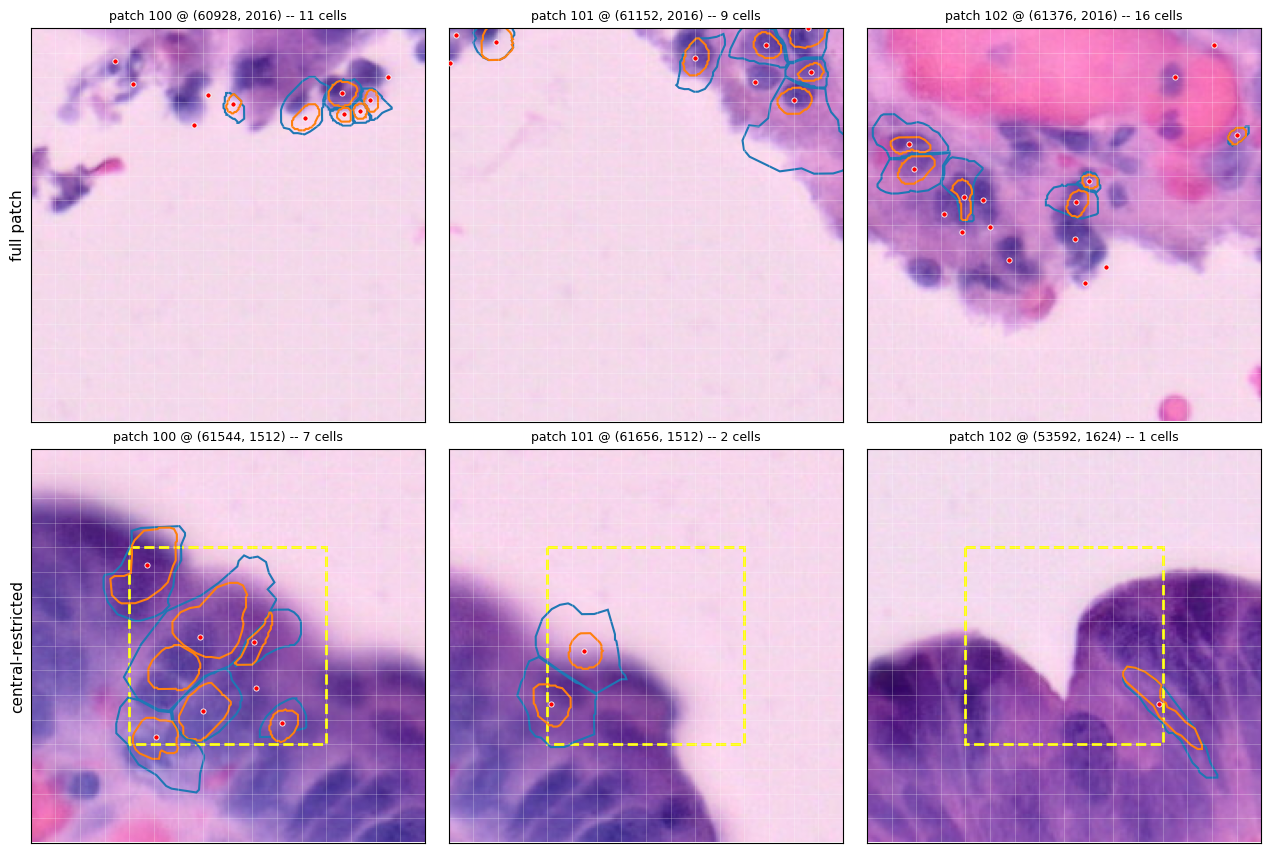

In [22]:
N_SHOW = 3
fig, axes = plt.subplots(2, N_SHOW, figsize=(4.3 * N_SHOW, 8.6))
for i in range(N_SHOW):
    plot_multicell_patch(dataset_full, i + 100, ax=axes[0, i], token_size=TOKEN_SIZE, show_boundaries=True)
    plot_multicell_patch(dataset_central, i+100, ax=axes[1, i], token_size=TOKEN_SIZE, show_boundaries=True)
axes[0, 0].set_ylabel("full patch", fontsize=11)
axes[1, 0].set_ylabel("central-restricted", fontsize=11)
plt.tight_layout()
plt.show()

## Resize component

`size_side_x`/`size_side_y` crop each tile at a different native pixel size than the
model's input, then resize it down (or up) to `X_SIZE`×`Y_SIZE`. This mirrors the
per-cell `ResizedCellDataset(size=X_SIZE, size_side=...)` "magnification-corrected"
setup (see the `UNI2_448` condition in `extract_embeddings.py`'s `__main__`), applied
to the multicell tiling loop instead of a per-cell crop. Cell markers and boundary
polygons are computed in the *output* frame, so they should still land exactly on the
right cells regardless of the native crop size.

Loading WSI from /cluster/work/boeva/mglettig/scHNE/complete_xenium_samples/H&E/Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE_he_image.ome.tif and cell info from /cluster/work/boeva/mglettig/scHNE/complete_xenium_samples/processed_output/Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE/patch_coordinates.h5...
Found 2330 non-empty patches covering 263823 cells (native crop 448x448, resized to 224x224).
resized tiling: 2330 patches, 263823 cells (native 448x448 crop -> 224x224)


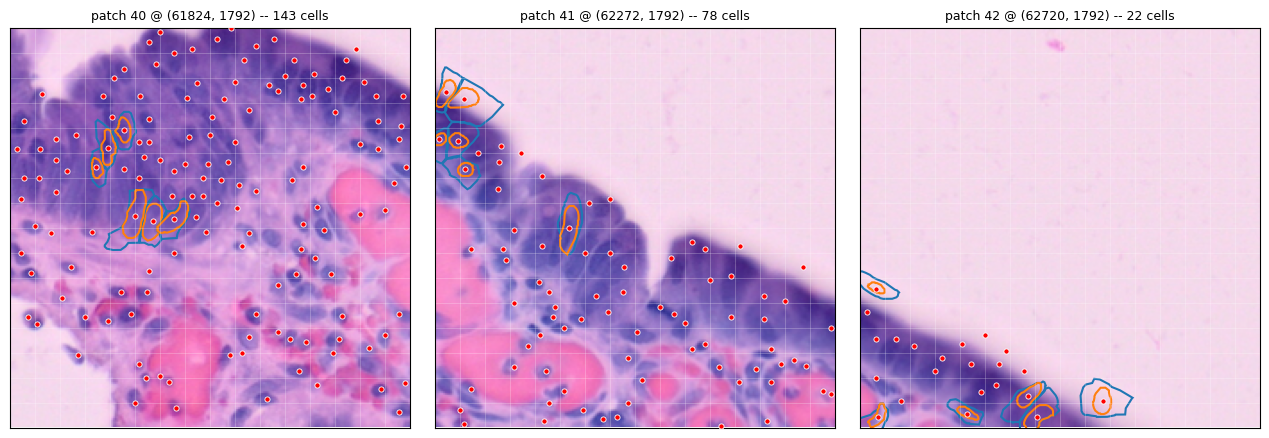

In [21]:
RESIZE_SIDE = 2 * X_SIZE  # crop at native double resolution, then resize back down to X_SIZE

dataset_resized = MultiCellPatchDataset(
    wsi_path=wsi_path,
    cells_info_path=cells_info_path,
    x_size=X_SIZE, y_size=Y_SIZE,
    size_side_x=RESIZE_SIDE, size_side_y=RESIZE_SIDE,
    cells_csv_path=cells_csv_path,
    nucleus_boundaries_path=nucleus_boundaries_path,
    alignment_matrix_path=alignment_matrix_path,
)
print(f"resized tiling: {len(dataset_resized)} patches, {dataset_resized.total_cells} cells "
      f"(native {RESIZE_SIDE}x{RESIZE_SIDE} crop -> {X_SIZE}x{Y_SIZE})")

fig, axes = plt.subplots(1, N_SHOW, figsize=(4.3 * N_SHOW, 4.3))
for i, ax in enumerate(axes):
    plot_multicell_patch(dataset_resized, i+40, ax=ax, token_size=TOKEN_SIZE, show_boundaries=True)
plt.tight_layout()
plt.show()

## Cell / nucleus boundary tokens in the multicell setting

For a few individual cells, `plot_cell_token_overlap` draws the token grid, both
Xenium boundary polygons, and the tokens whose footprint overlaps each one --
exactly what `InferenceProvider.pool_boundary_tokens_multicell` mean-pools over for
`embeddings_cell` / `embeddings_nucleus` in multicell mode. A polygon with no
overlapping token is drawn hatched (nearest-token fallback), matching the `WARNING:
no {kind} token overlap ...` printed during real extraction.

In [8]:
def plot_cell_token_overlap(dataset, patch_idx, local_idx, token_size=TOKEN_SIZE, ax=None):
    grid_size = dataset.x_size // token_size
    raw_patch = dataset.get_raw_patch(patch_idx)
    cell_id = dataset.patch_infos[patch_idx]["cell_ids"][local_idx]
    cell_id_str = cell_id.decode("utf-8") if isinstance(cell_id, bytes) else str(cell_id)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(raw_patch)

    for t in range(0, dataset.x_size + 1, token_size):
        ax.axvline(t, color="white", linewidth=0.5, alpha=0.5)
        ax.axhline(t, color="white", linewidth=0.5, alpha=0.5)

    for kind, color in _KIND_COLORS.items():
        polygon = dataset.boundary_polygon(patch_idx, local_idx, kind)
        if polygon is None:
            continue
        for ring in _exterior_rings(polygon):
            ax.add_patch(MplPolygon(ring, closed=True, facecolor="none", edgecolor=color, linewidth=2))
        mask = token_overlap_mask(polygon, 0, 0, token_size, grid_size)
        if mask.any():
            for r, c in zip(*np.where(mask)):
                ax.add_patch(Rectangle((c * token_size, r * token_size), token_size, token_size,
                                        facecolor=color, alpha=0.3, edgecolor="none"))
        else:
            r, c = nearest_token(polygon, 0, 0, token_size, grid_size)
            ax.add_patch(Rectangle((c * token_size, r * token_size), token_size, token_size,
                                    facecolor="none", edgecolor=color, hatch="//", linewidth=1.5))
            print(f"WARNING: no {kind} token overlap for patch_idx={patch_idx} local_idx={local_idx} "
                  f"-- showing nearest-token fallback (row={r}, col={c}).")

    rel_x = dataset.patch_infos[patch_idx]["cell_rel_x"][local_idx]
    rel_y = dataset.patch_infos[patch_idx]["cell_rel_y"][local_idx]
    ax.scatter([rel_x], [rel_y], s=25, c="red", edgecolors="white", linewidths=0.6, zorder=5)

    ax.set_xlim(0, dataset.x_size)
    ax.set_ylim(dataset.y_size, 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"cell {cell_id_str}", fontsize=9)
    return ax


def first_n_boundary_cells(dataset, n, kind="cell"):
    """First n (patch_idx, local_idx) pairs that have a `kind` boundary polygon."""
    found = []
    for patch_idx, p in enumerate(dataset.patch_infos):
        for local_idx in range(len(p["cell_ids"])):
            if dataset.boundary_polygon(patch_idx, local_idx, kind) is not None:
                found.append((patch_idx, local_idx))
                if len(found) >= n:
                    return found
    return found

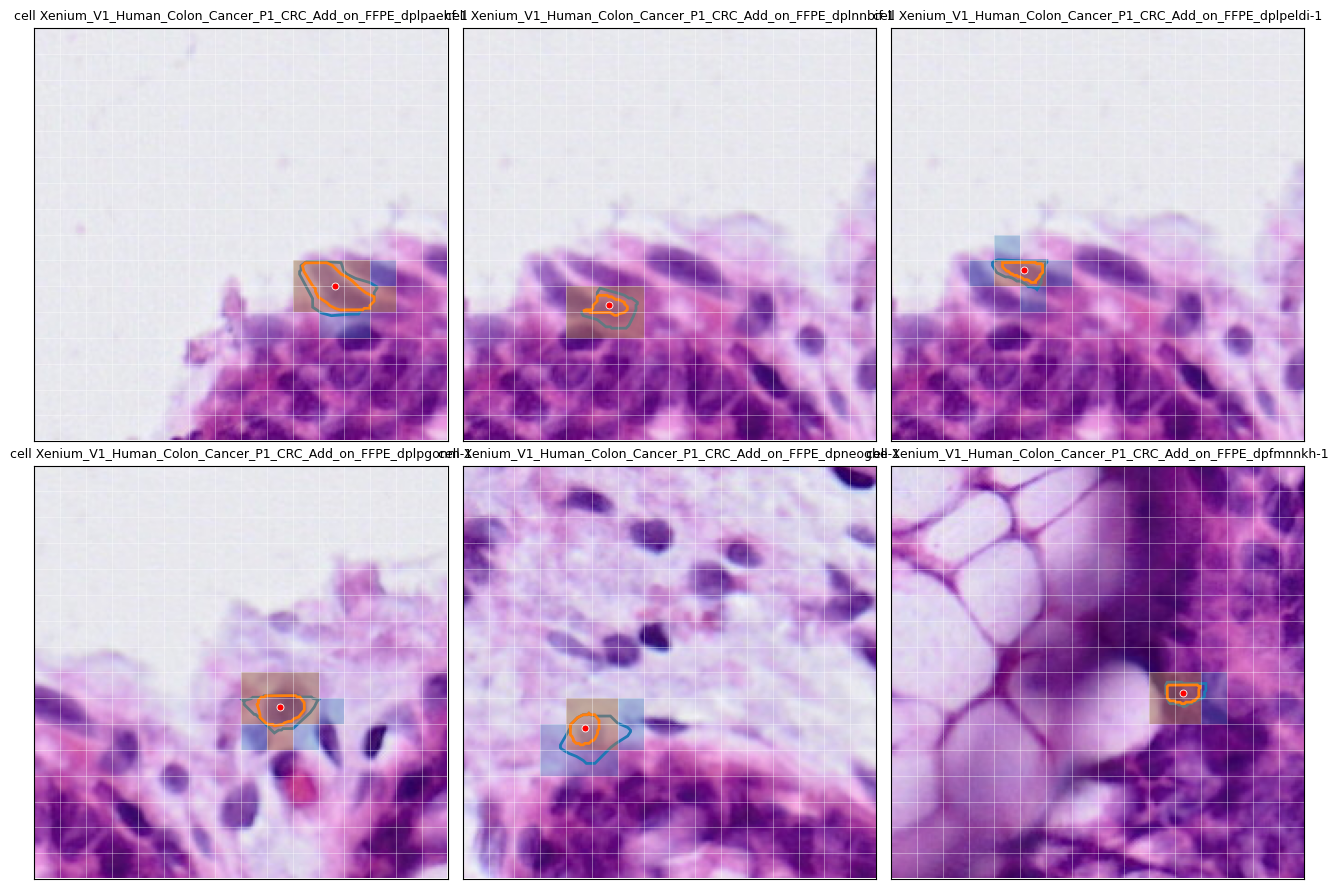

In [9]:
sample_cells = first_n_boundary_cells(dataset_central, 6)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for (patch_idx, local_idx), ax in zip(sample_cells, axes.flat):
    plot_cell_token_overlap(dataset_central, patch_idx, local_idx, ax=ax)
plt.tight_layout()
plt.show()

## Fallback-rate sanity scan

Same overlap check as above (no plotting), over a random sample of cells drawn from
the central-restricted dataset -- a high fallback rate is a red flag for a wrong
alignment matrix / mpp / coordinate-frame assumption rather than genuinely tiny
nuclei (see `notebooks/verify_boundary_tokens.ipynb` for the same check on the
per-cell extraction path).

In [10]:
def cell_at(dataset, flat_index):
    """Map a flat 0..total_cells-1 index to (patch_idx, local_idx)."""
    remaining = flat_index
    for patch_idx, p in enumerate(dataset.patch_infos):
        n = len(p["cell_ids"])
        if remaining < n:
            return patch_idx, remaining
        remaining -= n
    raise IndexError(flat_index)


N_CHECK = min(500, dataset_central.total_cells)
rng = random.Random(0)
check_flat_indices = rng.sample(range(dataset_central.total_cells), N_CHECK)

counts = {"cell": {"total": 0, "missing_polygon": 0, "fallback": 0},
          "nucleus": {"total": 0, "missing_polygon": 0, "fallback": 0}}

for flat_idx in check_flat_indices:
    patch_idx, local_idx = cell_at(dataset_central, flat_idx)
    for kind in ("cell", "nucleus"):
        counts[kind]["total"] += 1
        polygon = dataset_central.boundary_polygon(patch_idx, local_idx, kind)
        if polygon is None:
            counts[kind]["missing_polygon"] += 1
            continue
        mask = token_overlap_mask(polygon, 0, 0, TOKEN_SIZE, X_SIZE // TOKEN_SIZE)
        if not mask.any():
            counts[kind]["fallback"] += 1

for kind, c in counts.items():
    print(f"{kind}: {c['total']} checked, "
          f"{c['missing_polygon']} missing polygon ({c['missing_polygon'] / c['total']:.1%}), "
          f"{c['fallback']} fell back to nearest token ({c['fallback'] / c['total']:.1%})")

cell: 500 checked, 0 missing polygon (0.0%), 0 fell back to nearest token (0.0%)
nucleus: 500 checked, 0 missing polygon (0.0%), 0 fell back to nearest token (0.0%)


## Running this at scale

Once the config above looks right, wire the same knobs into a real extraction run:

```python
from src.python.extract_embeddings.extract_embeddings import build_multicell_configs, extract_embeddings_multicell

infos = {DATASET_NAME: {"converted": False, "model_output_dir": "UNI2"}}

configs = build_multicell_configs(
    "UNI2", infos,
    x_size=X_SIZE, y_size=Y_SIZE,
    size_side_x=RESIZE_SIDE, size_side_y=RESIZE_SIDE,       # omit for no resize
    central_size_x=CENTRAL_SIZE, central_size_y=CENTRAL_SIZE,  # omit for no central restriction
    with_boundaries=True,
)
extract_embeddings_multicell(configs, save_cell=True, save_nucleus=True)
```